In [13]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

## Detailed Data Cleaning, EDA, and Feature Engineering

This section performs a complete quality check, exploratory analysis, and feature engineering workflow for the customer churn dataset before model training.

In [ ]:
import numpy as np

# Load and inspect the raw data
df = pd.read_csv('data/Churn_Modelling.csv').copy()
print('Initial shape:', df.shape)
print(df.head())

# Check for duplicates and missing data
print('Duplicate rows:', df.duplicated().sum())
print('Missing values:\n', df.isnull().sum())

# Drop identifier columns that do not add predictive signal
drop_columns = ['RowNumber', 'CustomerId', 'Surname']
df = df.drop(columns=[col for col in drop_columns if col in df.columns], errors='ignore')
print('Remaining columns:', list(df.columns))

Initial shape: (10000, 14)
   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826

### .Handling Outliers

In [15]:
# Convert categorical columns to category dtype for cleaner analysis
df['Geography'] = df['Geography'].astype('category')
df['Gender'] = df['Gender'].astype('category')
df['Exited'] = df['Exited'].astype(int)

# Use a compact data-quality summary
print(df.dtypes)
print(df.describe().T)

# IQR-based outlier scan
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f'{col}: {len(outliers)} outliers using the IQR rule')
    df= df[(df[col] > lower) & (df[col] < upper)]

print('\n final shape: ', df.shape)

CreditScore           int64
Geography          category
Gender             category
Age                   int64
Tenure                int64
Balance             float64
NumOfProducts         int64
HasCrCard             int64
IsActiveMember        int64
EstimatedSalary     float64
Exited                int64
dtype: object
                   count           mean           std     min       25%  \
CreditScore      10000.0     650.528800     96.653299  350.00    584.00   
Age              10000.0      38.921800     10.487806   18.00     32.00   
Tenure           10000.0       5.012800      2.892174    0.00      3.00   
Balance          10000.0   76485.889288  62397.405202    0.00      0.00   
NumOfProducts    10000.0       1.530200      0.581654    1.00      1.00   
HasCrCard        10000.0       0.705500      0.455840    0.00      0.00   
IsActiveMember   10000.0       0.515100      0.499797    0.00      0.00   
EstimatedSalary  10000.0  100090.239881  57510.492818   11.58  51002.11   
Exi

## Exploratory Data Analysis (EDA)

This section studies the target distribution, category-level churn patterns, numerical feature distributions, and relationships between features and churn outcome.

Overall churn rate: 19.64%
Exited
0    0.803573
1    0.196427
Name: proportion, dtype: float64


C:\Users\z1652\AppData\Local\Temp\ipykernel_16732\955795172.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Exited', palette='Set2')


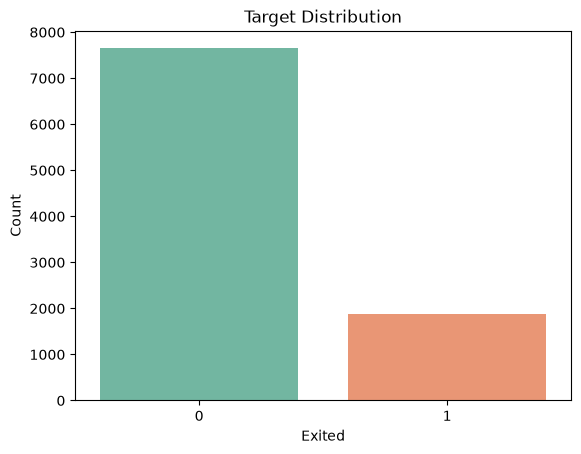

In [16]:
# Target analysis
churn_rate = df['Exited'].mean() * 100
print(f'Overall churn rate: {churn_rate:.2f}%')
print(df['Exited'].value_counts(normalize=True).sort_index())

sns.countplot(data=df, x='Exited', palette='Set2')
plt.title('Target Distribution')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.show()

C:\Users\z1652\AppData\Local\Temp\ipykernel_16732\648845346.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='Exited', estimator='mean', errorbar=None, palette='viridis')


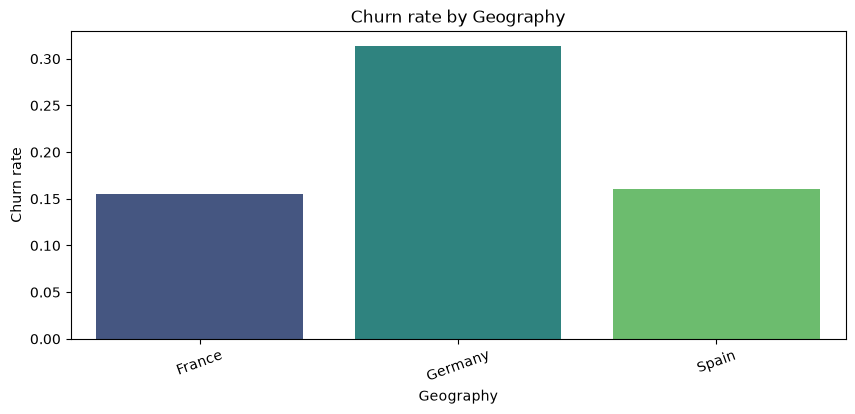

C:\Users\z1652\AppData\Local\Temp\ipykernel_16732\648845346.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='Exited', estimator='mean', errorbar=None, palette='viridis')


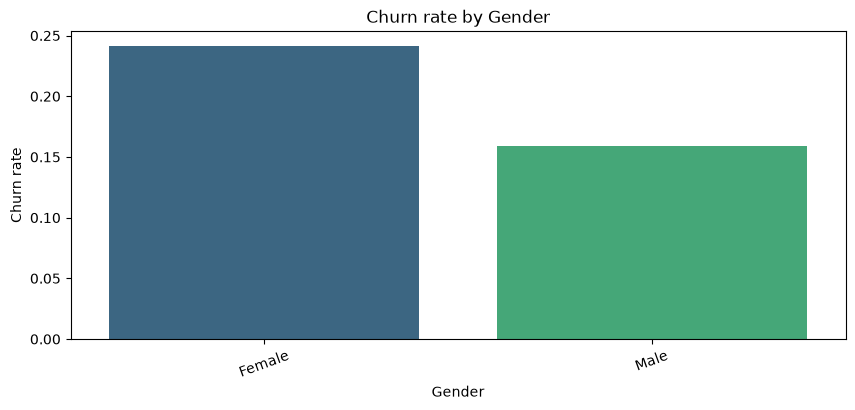

C:\Users\z1652\AppData\Local\Temp\ipykernel_16732\648845346.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='Exited', estimator='mean', errorbar=None, palette='viridis')


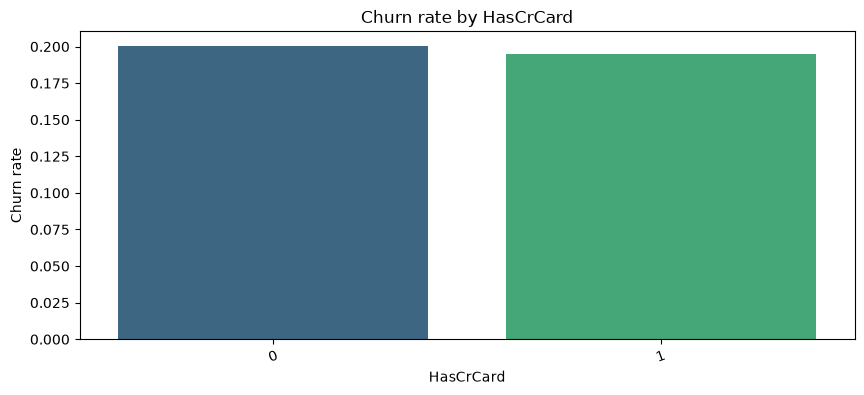

C:\Users\z1652\AppData\Local\Temp\ipykernel_16732\648845346.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x=col, y='Exited', estimator='mean', errorbar=None, palette='viridis')


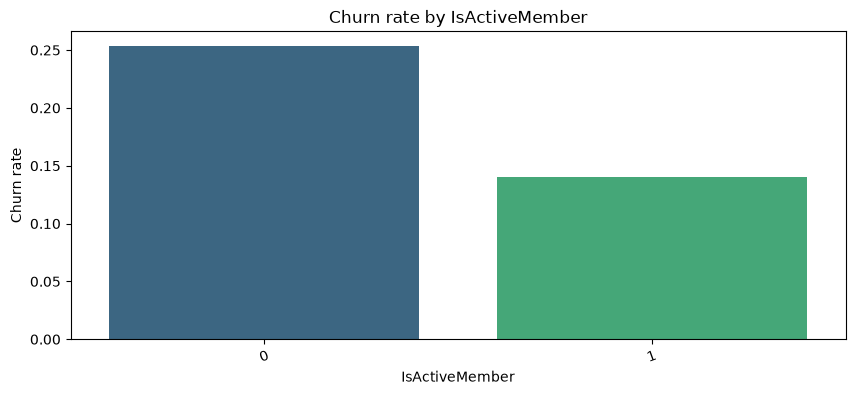

In [17]:
# Categorical churn risk by geography and gender
for col in ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']:
    plt.figure(figsize=(10, 4))
    sns.barplot(data=df, x=col, y='Exited', estimator='mean', errorbar=None, palette='viridis')
    plt.title(f'Churn rate by {col}')
    plt.ylabel('Churn rate')
    plt.xticks(rotation=20)
    plt.show()

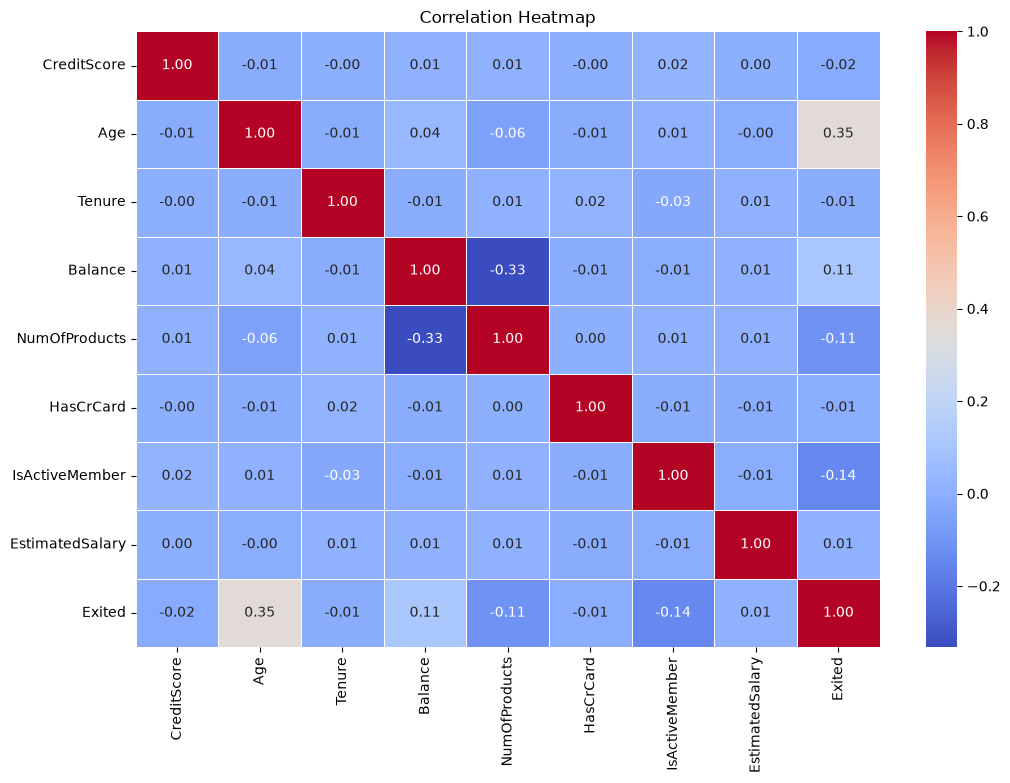

In [18]:
# Correlation heatmap for numeric variables
corr = df.select_dtypes(include=[np.number]).corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

## Feature Engineering

This stage creates additional signals that are often important for customer churn modeling, including balance-to-income relationships, customer behavior bands, and product engagement indicators.

In [25]:
# Create behavioral and financial feature ratios
df['BalanceToSalaryRatio'] = df['Balance'] / df['EstimatedSalary'].replace(0, np.nan)
df['BalanceToSalaryRatio'] = df['BalanceToSalaryRatio'].fillna(0)

df['IsHighBalance'] = (df['Balance'] > df['Balance'].median()).astype(int)

df['IsMultiProductCustomer'] = (df['NumOfProducts'] > 1).astype(int)

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 25, 35, 45, 55, 65, 100],
    labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'],
    include_lowest=True
)
df['CreditScoreBand'] = pd.cut(
    df['CreditScore'],
    bins=[0, 400, 600, 700, 800, 900],
    labels=['Low', 'Fair', 'Good', 'Very Good', 'Excellent'],
    right=False
)
df['TenurePerAge'] = df['Tenure'] / df['Age'].replace(0, np.nan)
df['TenurePerAge'] = df['TenurePerAge'].fillna(0)

# Optional derived interaction feature
df['ActiveMember_And_MultiProduct'] = df['IsActiveMember'] * df['IsMultiProductCustomer']

df.shape

(9515, 18)

### Saving the Dataset

In [26]:
df.to_csv('Churn_Modelling_cleaned.csv', index=False)

#### Encoding

In [20]:
# Encode categorical features for model-ready training data
categorical_for_encoding = ['Geography', 'Gender', 'AgeGroup', 'CreditScoreBand']
encoded = pd.get_dummies(df[categorical_for_encoding], drop_first=True, dtype=int)
df_model = pd.concat([df.drop(columns=categorical_for_encoding), encoded], axis=1)

print(df_model.head())
print('Prepared dataset shape:', df_model.shape)

   CreditScore  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
0          619   42       2       0.00              1          1   
1          608   41       1   83807.86              1          0   
2          502   42       8  159660.80              3          1   
3          699   39       1       0.00              2          0   
4          850   43       2  125510.82              1          1   

   IsActiveMember  EstimatedSalary  Exited  BalanceToSalaryRatio  ...  \
0               1        101348.88       1              0.000000  ...   
1               1        112542.58       0              0.744677  ...   
2               0        113931.57       1              1.401375  ...   
3               0         93826.63       0              0.000000  ...   
4               1         79084.10       0              1.587055  ...   

   Gender_Male  AgeGroup_26-35  AgeGroup_36-45  AgeGroup_46-55  \
0            0               0               1               0   
1            0      

In [21]:
# Final matrix ready for a churn model
X = df_model.drop(columns=['Exited'])
y = df_model['Exited']

print('Feature columns:', list(X.columns))
print('Target shape:', y.shape)
print('Input matrix shape:', X.shape)

Feature columns: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'BalanceToSalaryRatio', 'IsHighBalance', 'IsMultiProductCustomer', 'TenurePerAge', 'ActiveMember_And_MultiProduct', 'Geography_Germany', 'Geography_Spain', 'Gender_Male', 'AgeGroup_26-35', 'AgeGroup_36-45', 'AgeGroup_46-55', 'AgeGroup_56-65', 'AgeGroup_65+', 'CreditScoreBand_Fair', 'CreditScoreBand_Good', 'CreditScoreBand_Very Good', 'CreditScoreBand_Excellent']
Target shape: (9515,)
Input matrix shape: (9515, 25)


#### Normalization

In [22]:
numeric_cols = ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary', 'BalanceToSalaryRatio', 'TenurePerAge']
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X[numeric_cols])
X[numeric_cols] = scaler.transform(X[numeric_cols])
# pd.DataFrame(scaler.inverse_transform(X[numeric_cols]), columns=numeric_cols)  # Optional: to check the inverse transformation


In [23]:
pd.DataFrame(X).info()

<class 'pandas.DataFrame'>
Index: 9515 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   CreditScore                    9515 non-null   float64
 1   Age                            9515 non-null   float64
 2   Tenure                         9515 non-null   float64
 3   Balance                        9515 non-null   float64
 4   NumOfProducts                  9515 non-null   float64
 5   HasCrCard                      9515 non-null   int64  
 6   IsActiveMember                 9515 non-null   int64  
 7   EstimatedSalary                9515 non-null   float64
 8   BalanceToSalaryRatio           9515 non-null   float64
 9   IsHighBalance                  9515 non-null   int64  
 10  IsMultiProductCustomer         9515 non-null   int64  
 11  TenurePerAge                   9515 non-null   float64
 12  ActiveMember_And_MultiProduct  9515 non-null   int64  
 13  Geog

In [24]:
# df_model.select_dtypes(include='bool').astype(int)